# 🌱 Python para análisis estadístico en Biología

## Notebook resuelto

Este notebook reúne los contenidos esenciales para una sesión introductoria de análisis estadístico con Python, con ejemplos orientados a biología vegetal.

### Objetivos

Al finalizar, deberíamos ser capaces de:

- resumir un conjunto de datos mediante estadística descriptiva;
- visualizar distribuciones y comparar grupos;
- formular e interpretar hipótesis estadísticas;
- aplicar un **t-test** para comparar dos grupos;
- aplicar un **ANOVA de una vía** para comparar tres o más grupos;
- entender por qué se utilizan comparaciones **post-hoc**;
- mencionar alternativas no paramétricas;
- ajustar modelos no lineales mediante `scipy.optimize.curve_fit`;
- interpretar parámetros de modelos logístico y Gompertz;
- integrar varias de estas herramientas en un problema biológico completo.

> **Importante:** la estadística no consiste solamente en ejecutar una función.  
> Antes de aplicar un test debemos entender qué pregunta queremos responder y cuáles son sus supuestos.

# 1. Importación de librerías

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import curve_fit

np.random.seed(42)

# 2. Estadística descriptiva

La estadística descriptiva resume las principales características de los datos.

Algunas medidas frecuentes son:

- media;
- mediana;
- mínimo y máximo;
- varianza;
- desviación estándar;
- percentiles.

La **media** describe el centro de los datos, mientras que la **desviación estándar** describe cuánto se dispersan alrededor de la media.

In [6]:
# Altura de 10 plantas, en centímetros

alturas = np.array([18.2, 19.1, 17.8, 20.3, 21.0, 18.9, 19.7, 20.1, 18.5, 19.4])

print("n =", len(alturas))
print("Media =", np.mean(alturas))
print("Mediana =", np.median(alturas))
print("Mínimo =", np.min(alturas))
print("Máximo =", np.max(alturas))
print("Varianza muestral =", np.var(alturas))
print("Desviación estándar muestral =", np.std(alturas))
print("Percentil 25 =", np.percentile(alturas, 25))
print("Percentil 75 =", np.percentile(alturas, 75))

n = 10
Media = 19.3
Mediana = 19.25
Mínimo = 17.8
Máximo = 21.0
Varianza muestral = 0.9000000000000001
Desviación estándar muestral = 0.9486832980505139
Percentil 25 = 18.6
Percentil 75 = 20.0


## Visualización rápida de una distribución

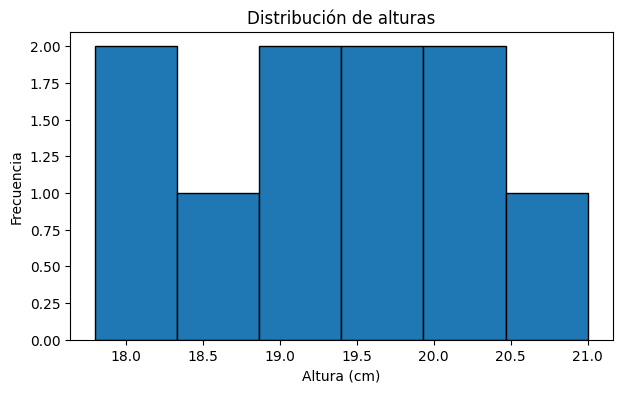

In [7]:
plt.figure(figsize=(7, 4))
plt.hist(alturas, bins=6, edgecolor="black")
plt.xlabel("Altura (cm)")
plt.ylabel("Frecuencia")
plt.title("Distribución de alturas")
plt.show()

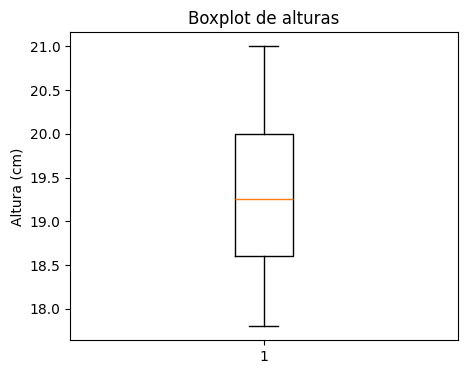

In [8]:
plt.figure(figsize=(5, 4))
plt.boxplot(alturas)
plt.ylabel("Altura (cm)")
plt.title("Boxplot de alturas")
plt.show()

# 3. De la descripción a la inferencia

Supongamos que queremos comparar dos tratamientos.

Tenemos:

- **Control**
- **Tratamiento**

La estadística descriptiva puede mostrarnos que sus medias son distintas, pero necesitamos preguntarnos:

> ¿La diferencia observada podría explicarse simplemente por variabilidad aleatoria?

Aquí comienza la **inferencia estadística**.

## Hipótesis nula y alternativa

Para comparar dos medias:

$$
H_0: \mu_{\text{control}} = \mu_{\text{tratamiento}}
$$

$$
H_1: \mu_{\text{control}} \neq \mu_{\text{tratamiento}}
$$

La hipótesis nula representa el escenario de referencia: **no existe diferencia entre las medias poblacionales**.

## p-value

El p-value puede interpretarse como:

> La probabilidad de observar un resultado tan extremo como el obtenido, o más extremo, **suponiendo que la hipótesis nula sea verdadera**.

No significa:

* la probabilidad de que la hipótesis nula sea cierta;
* la probabilidad de que nuestro resultado sea correcto;
* el tamaño del efecto biológico.

Utilizaremos convencionalmente:

$$
\alpha = 0.05
$$

Si:

$$
p < 0.05
$$

diremos que existe evidencia suficiente para **rechazar** la hipótesis nula.

Si:

$$
p \geq 0.05
$$

diremos que **no existe evidencia suficiente para rechazarla**.

No debemos decir que hemos demostrado que los grupos son iguales.

# 4. Comparación de dos grupos: t-test

In [9]:
control = np.array([18.2, 19.1, 17.8, 20.3, 18.9, 19.5, 18.7, 19.0])
tratamiento = np.array([21.0, 22.1, 20.7, 23.0, 21.8, 22.4, 21.5, 22.0])

print("Media control:", np.mean(control))
print("Media tratamiento:", np.mean(tratamiento))

Media control: 18.9375
Media tratamiento: 21.8125


/tmp/ipykernel_844/3208075217.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([control, tratamiento], labels=["Control", "Tratamiento"])


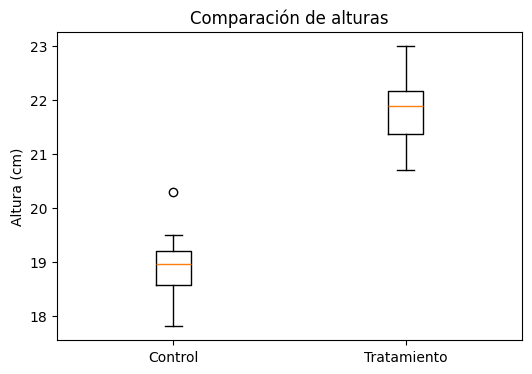

In [10]:
plt.figure(figsize=(6, 4))
plt.boxplot([control, tratamiento], labels=["Control", "Tratamiento"])
plt.ylabel("Altura (cm)")
plt.title("Comparación de alturas")
plt.show()

## t-test de muestras independientes

Usaremos el **t-test de Welch**:

```python
stats.ttest_ind(grupo1, grupo2, equal_var=False)
```

Es una versión del t-test que no requiere asumir igualdad de varianzas.

In [11]:
resultado = stats.ttest_ind(control, tratamiento, equal_var=False)

print("Estadístico t =", resultado.statistic)
print("p-value =", resultado.pvalue)

Estadístico t = -7.622033030088923
p-value = 2.4069354827681957e-06


In [12]:
alpha = 0.05

if resultado.pvalue < alpha:
    print("Rechazamos H0: existe evidencia de una diferencia entre los grupos.")
else:
    print("No rechazamos H0: no existe evidencia suficiente de una diferencia.")

Rechazamos H0: existe evidencia de una diferencia entre los grupos.


## Tamaño del efecto

Una diferencia puede ser estadísticamente significativa pero biológicamente pequeña.

Podemos calcular una diferencia absoluta entre medias:

In [13]:
diferencia = np.mean(tratamiento) - np.mean(control)
print("Diferencia de medias:", diferencia, "cm")

Diferencia de medias: 2.875 cm


Una interpretación razonable debería mencionar tanto:

- evidencia estadística;
- magnitud de la diferencia.

# 5. t-test pareado

Un test pareado se utiliza cuando las observaciones están relacionadas.

Ejemplo:

- medir las mismas plantas antes y después de un tratamiento;
- comparar dos condiciones sobre el mismo individuo.

En este caso **no** debemos usar un t-test independiente.

In [14]:
antes = np.array([10.2, 11.1, 9.8, 10.5, 11.0, 10.8])
despues = np.array([11.4, 12.0, 10.7, 11.2, 11.9, 11.5])

resultado_pareado = stats.ttest_rel(antes, despues)

print("t =", resultado_pareado.statistic)
print("p =", resultado_pareado.pvalue)

t = -11.792345226484555
p = 7.716322242073264e-05


# 6. La unidad experimental y la pseudorreplicación

Supongamos:

- 3 plantas control;
- 3 plantas tratamiento;
- 10 hojas medidas por planta.

Aunque tengamos 30 mediciones de hojas por grupo, **no necesariamente tenemos 30 réplicas biológicas independientes**.

Las hojas de una misma planta comparten el mismo organismo, ambiente y contexto experimental.

Tratar todas las hojas como réplicas independientes puede producir una falsa sensación de tamaño muestral grande y p-values artificialmente pequeños.

> Antes de aplicar un test, debemos identificar correctamente cuál es la unidad experimental.

# 7. Comparación de tres o más grupos: ANOVA de una vía

Supongamos ahora que tenemos:

* Control
* Fertilizante A
* Fertilizante B

El ANOVA plantea:

$$
H_0: \mu_C = \mu_A = \mu_B
$$

La hipótesis alternativa establece que **al menos una media difiere**.

In [15]:
control = np.array([18.1, 19.0, 18.5, 19.3, 18.8, 19.1])
fert_a  = np.array([20.1, 20.5, 19.8, 21.0, 20.7, 20.3])
fert_b  = np.array([23.0, 22.4, 23.5, 22.9, 23.2, 22.7])

resultado_anova = stats.f_oneway(control, fert_a, fert_b)

print("F =", resultado_anova.statistic)
print("p =", resultado_anova.pvalue)

F = 150.77437858508625
p = 1.167830591229314e-10


/tmp/ipykernel_844/3039348036.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([control, fert_a, fert_b],


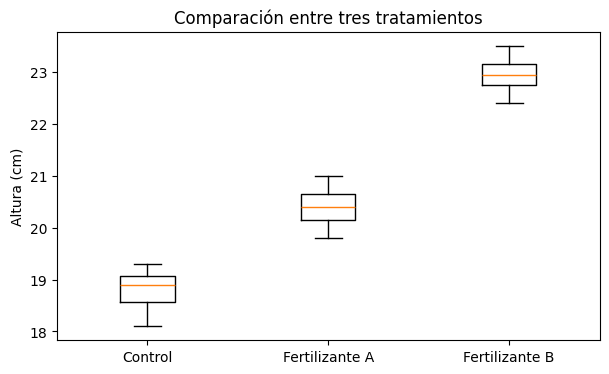

In [16]:
plt.figure(figsize=(7, 4))
plt.boxplot([control, fert_a, fert_b],
            labels=["Control", "Fertilizante A", "Fertilizante B"])
plt.ylabel("Altura (cm)")
plt.title("Comparación entre tres tratamientos")
plt.show()

## ¿Qué significa un ANOVA significativo?

Si:

$$
p < 0.05
$$

podemos decir:

> Existe evidencia de que no todas las medias son iguales.

Pero **NO** podemos concluir directamente:

* que todos los grupos sean diferentes;
* qué pares específicos difieren.

Para eso necesitamos comparaciones **post-hoc**.

# 8. Comparaciones post-hoc

Una estrategia habitual es utilizar **Tukey HSD**.

SciPy incluye:

```python
stats.tukey_hsd(...)
```

In [17]:
tukey = stats.tukey_hsd(control, fert_a, fert_b)
print(tukey)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -1.600     0.000    -2.226    -0.974
 (0 - 2)     -4.150     0.000    -4.776    -3.524
 (1 - 0)      1.600     0.000     0.974     2.226
 (1 - 2)     -2.550     0.000    -3.176    -1.924
 (2 - 0)      4.150     0.000     3.524     4.776
 (2 - 1)      2.550     0.000     1.924     3.176



La salida contiene comparaciones pareadas entre los grupos.

La lógica es:

1. ANOVA responde si existe evidencia global de diferencias.
2. Tukey ayuda a identificar qué pares presentan diferencias.

# 9. Métodos paramétricos y no paramétricos

En términos introductorios:

### Métodos paramétricos

Utilizan modelos que dependen de parámetros poblacionales y generalmente realizan ciertos supuestos sobre la distribución de los errores.

Ejemplos:

- t-test;
- ANOVA.

### Métodos no paramétricos

Realizan menos supuestos distribucionales y frecuentemente trabajan con rangos.

Algunas equivalencias útiles:

| Problema | Paramétrico | No paramétrico |
|---|---|---|
| Dos grupos independientes | t-test | Mann–Whitney U |
| Dos mediciones pareadas | t-test pareado | Wilcoxon |
| Tres o más grupos | ANOVA | Kruskal–Wallis |

No debemos simplificar esto como:

> "normal → paramétrico; no normal → no paramétrico"

La elección depende también del diseño experimental, independencia, tamaño muestral, outliers y pregunta científica.

In [19]:
# Ejemplo sencillo: Mann–Whitney U

grupo_a = np.array([2, 3, 3, 4, 4, 5])
grupo_b = np.array([6, 7, 8, 8, 9, 10])

resultado_mw = stats.mannwhitneyu(grupo_a, grupo_b, alternative="two-sided")

print("U =", resultado_mw.statistic)
print("p =", resultado_mw.pvalue)

U = 0.0
p = 0.0048466012104884885


# 10. Ajuste de modelos no lineales

En otros problemas no queremos comparar grupos, sino describir cómo una variable cambia en función de otra.

Por ejemplo:

> ¿Cómo cambia la biomasa de una planta a través del tiempo?

Podemos proponer una función:

$$
y = f(t, \theta)
$$

donde:

* $t$ es el tiempo;
* $y$ es la variable observada;
* $\theta$ representa los parámetros del modelo.

`scipy.optimize.curve_fit` estima los parámetros que mejor ajustan la curva a los datos.

# 11. Modelo logístico

Una forma habitual del modelo logístico es:

$$
y(t)=\frac{K}{1+e^{-r(t-t_0)}}
$$

donde:

* $K$: valor máximo o asíntota;
* $r$: tasa de crecimiento;
* $t_0$: tiempo del punto de inflexión.

In [20]:
def logistica(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

In [21]:
tiempo = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30], dtype=float)
biomasa = np.array([1.8, 2.3, 3.5, 5.7, 9.5, 15.0, 21.8, 27.0, 30.4, 32.1, 33.0])

p0 = [35, 0.25, 15]

parametros, covarianza = curve_fit(
    logistica,
    tiempo,
    biomasa,
    p0=p0,
    maxfev=10000
)

K, r, t0 = parametros

print("K =", K)
print("r =", r)
print("t0 =", t0)

K = 34.572708059496065
r = 0.23444370989909552
t0 = 15.863986123750845


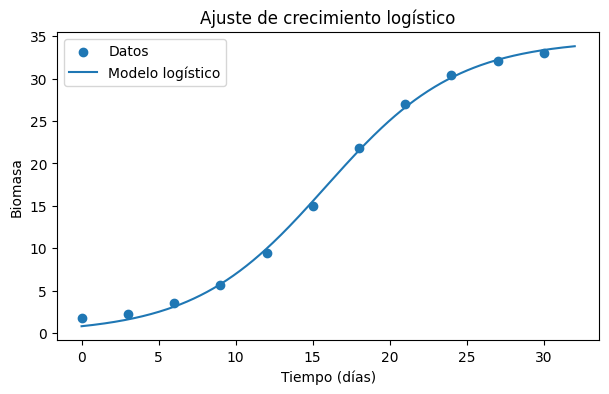

In [22]:
t_suave = np.linspace(0, 32, 300)
y_ajustada = logistica(t_suave, *parametros)

plt.figure(figsize=(7, 4))
plt.scatter(tiempo, biomasa, label="Datos")
plt.plot(t_suave, y_ajustada, label="Modelo logístico")
plt.xlabel("Tiempo (días)")
plt.ylabel("Biomasa")
plt.title("Ajuste de crecimiento logístico")
plt.legend()
plt.show()

## Interpretación

Si obtenemos aproximadamente:

* $K \approx 34$: el modelo predice que la biomasa se aproxima a ese valor máximo;
* $r$: describe la rapidez de la transición;
* $t_0$: indica aproximadamente cuándo ocurre el máximo crecimiento instantáneo.

En el modelo logístico estándar:

$$
y(t_0)=\frac{K}{2}
$$

# 12. Modelo de Gompertz

Otra función sigmoidea frecuente en biología es Gompertz:

$$
y(t)=K e^{-e^{-r(t-t_0)}}
$$

A diferencia de la logística, la curva de Gompertz es **asimétrica**.

In [23]:
def gompertz(t, K, r, t0):
    return K * np.exp(-np.exp(-r * (t - t0)))

In [24]:
parametros_g, covarianza_g = curve_fit(
    gompertz,
    tiempo,
    biomasa,
    p0=[35, 0.2, 12],
    maxfev=10000
)

print("Parámetros Gompertz:")
print("K =", parametros_g[0])
print("r =", parametros_g[1])
print("t0 =", parametros_g[2])

Parámetros Gompertz:
K = 38.67216772348711
r = 0.1294752151487568
t0 = 13.96294486522355


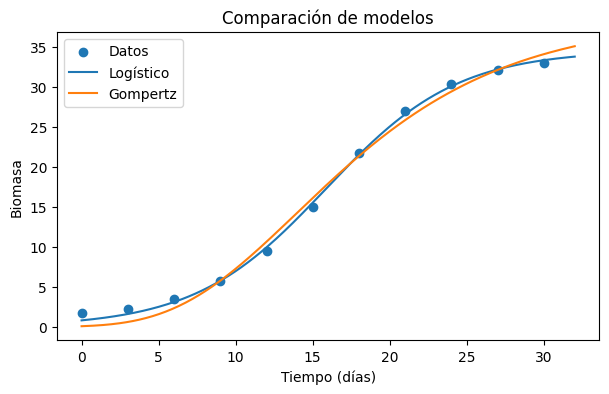

In [25]:
y_log = logistica(t_suave, *parametros)
y_gom = gompertz(t_suave, *parametros_g)

plt.figure(figsize=(7, 4))
plt.scatter(tiempo, biomasa, label="Datos")
plt.plot(t_suave, y_log, label="Logístico")
plt.plot(t_suave, y_gom, label="Gompertz")
plt.xlabel("Tiempo (días)")
plt.ylabel("Biomasa")
plt.title("Comparación de modelos")
plt.legend()
plt.show()

# 13. ¿Cómo comparar ajustes de manera simple?

Una opción introductoria consiste en comparar los residuos.

Para cada observación:

$$
e_i = y_i - \hat{y}_i
$$

y luego calcular el **error cuadrático medio**:

$$
MSE = \frac{1}{n}\sum_i (y_i-\hat{y}_i)^2
$$

Un MSE menor indica un ajuste más cercano a los datos observados, aunque no necesariamente implica que el modelo sea biológicamente mejor.


In [26]:
pred_log = logistica(tiempo, *parametros)
pred_gom = gompertz(tiempo, *parametros_g)

mse_log = np.mean((biomasa - pred_log)**2)
mse_gom = np.mean((biomasa - pred_gom)**2)

print("MSE logístico:", mse_log)
print("MSE Gompertz:", mse_gom)

MSE logístico: 0.23173592723908365
MSE Gompertz: 1.2121514661472657


# 14. Ejercicio Completo

## Situación

Se estudia el efecto de tres tratamientos sobre plantas:

- Control
- Fertilizante A
- Fertilizante B

Después de 30 días se mide la biomasa final.

Además, para el tratamiento B se registra la biomasa a través del tiempo.

### Objetivos

1. Resumir los datos.
2. Visualizar los tratamientos.
3. Aplicar un ANOVA.
4. Si corresponde, realizar Tukey HSD.
5. Interpretar la magnitud de las diferencias.
6. Ajustar un modelo logístico al crecimiento del tratamiento B.
7. Interpretar sus parámetros.

In [27]:
control = np.array([21.4, 20.8, 22.1, 21.7, 20.9, 21.3, 22.0, 21.1])
fert_a = np.array([24.8, 25.1, 24.2, 25.5, 24.9, 25.3, 24.6, 25.0])
fert_b = np.array([30.1, 29.4, 30.8, 31.0, 29.9, 30.5, 30.2, 29.7])

grupos = {
    "Control": control,
    "Fertilizante A": fert_a,
    "Fertilizante B": fert_b
}

## Parte 1 — Estadística descriptiva

In [28]:
for nombre, datos in grupos.items():
    print(nombre)
    print("  n:", len(datos))
    print("  media:", np.mean(datos))
    print("  mediana:", np.median(datos))
    print("  desviación estándar:", np.std(datos, ddof=1))
    print()

Control
  n: 8
  media: 21.4125
  mediana: 21.35
  desviación estándar: 0.48532021829480215

Fertilizante A
  n: 8
  media: 24.925000000000004
  mediana: 24.95
  desviación estándar: 0.40620192023179824

Fertilizante B
  n: 8
  media: 30.2
  mediana: 30.15
  desviación estándar: 0.5451081150953981



## Parte 2 — Visualización

/tmp/ipykernel_844/1160041152.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


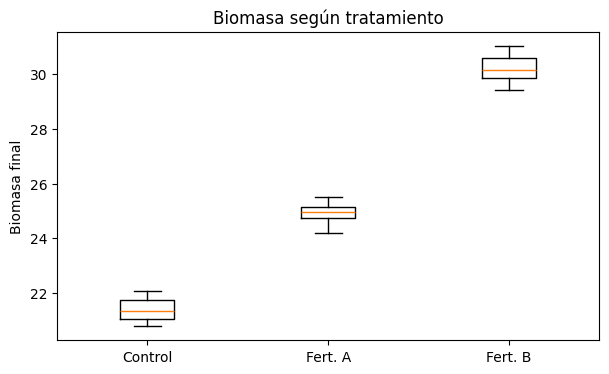

In [29]:
plt.figure(figsize=(7, 4))
plt.boxplot(
    [control, fert_a, fert_b],
    labels=["Control", "Fert. A", "Fert. B"]
)
plt.ylabel("Biomasa final")
plt.title("Biomasa según tratamiento")
plt.show()

## Parte 3 — ANOVA

### Hipótesis

$$
H_0: \mu_C = \mu_A = \mu_B
$$

$$
H_1: \text{al menos una media difiere}
$$

In [30]:
anova = stats.f_oneway(control, fert_a, fert_b)

print("F =", anova.statistic)
print("p =", anova.pvalue)

F = 672.9943690811336
p = 9.073414675709578e-20


In [31]:
alpha = 0.05

if anova.pvalue < alpha:
    print("Existe evidencia estadística de diferencias entre los tratamientos.")
else:
    print("No existe evidencia suficiente para afirmar diferencias entre los tratamientos.")

Existe evidencia estadística de diferencias entre los tratamientos.


## Parte 4 — Tukey HSD

In [32]:
tukey = stats.tukey_hsd(control, fert_a, fert_b)
print(tukey)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -3.513     0.000    -4.120    -2.905
 (0 - 2)     -8.787     0.000    -9.395    -8.180
 (1 - 0)      3.513     0.000     2.905     4.120
 (1 - 2)     -5.275     0.000    -5.883    -4.667
 (2 - 0)      8.787     0.000     8.180     9.395
 (2 - 1)      5.275     0.000     4.667     5.883



## Parte 5 — Magnitud de las diferencias

In [33]:
media_control = np.mean(control)
media_a = np.mean(fert_a)
media_b = np.mean(fert_b)

print("Media Control:", media_control)
print("Media Fertilizante A:", media_a)
print("Media Fertilizante B:", media_b)

print()
print("A - Control:", media_a - media_control)
print("B - Control:", media_b - media_control)
print("B - A:", media_b - media_a)

Media Control: 21.4125
Media Fertilizante A: 24.925000000000004
Media Fertilizante B: 30.2

A - Control: 3.512500000000003
B - Control: 8.787499999999998
B - A: 5.274999999999995


### Interpretación

Una conclusión adecuada combinaría:

- el resultado del ANOVA;
- las comparaciones post-hoc;
- la magnitud de las diferencias.

No basta con escribir únicamente:

> p < 0.05

También debemos explicar **qué grupos difieren** y **cuánto difieren**.

## Parte 6 — Crecimiento temporal del tratamiento B

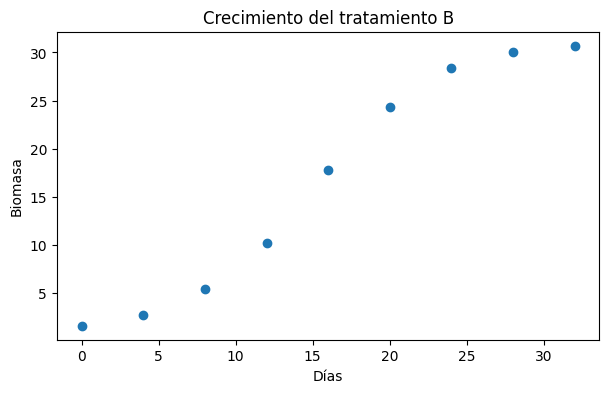

In [34]:
dias = np.array([0, 4, 8, 12, 16, 20, 24, 28, 32], dtype=float)
biomasa_b = np.array([1.6, 2.7, 5.4, 10.2, 17.8, 24.3, 28.4, 30.0, 30.7])

plt.figure(figsize=(7, 4))
plt.scatter(dias, biomasa_b)
plt.xlabel("Días")
plt.ylabel("Biomasa")
plt.title("Crecimiento del tratamiento B")
plt.show()

## Parte 7 — Ajuste logístico

In [35]:
params_b, cov_b = curve_fit(
    logistica,
    dias,
    biomasa_b,
    p0=[31, 0.25, 15],
    maxfev=10000
)

K_b, r_b, t0_b = params_b

print("K =", K_b)
print("r =", r_b)
print("t0 =", t0_b)

K = 31.516223850044444
r = 0.23146161480236793
t0 = 14.883765308197185


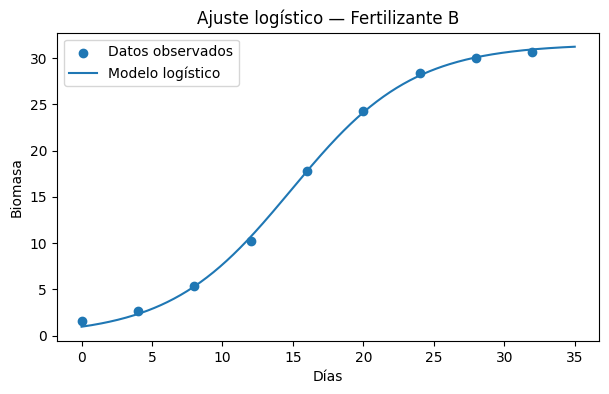

In [36]:
dias_suaves = np.linspace(0, 35, 300)
pred_b = logistica(dias_suaves, *params_b)

plt.figure(figsize=(7, 4))
plt.scatter(dias, biomasa_b, label="Datos observados")
plt.plot(dias_suaves, pred_b, label="Modelo logístico")
plt.xlabel("Días")
plt.ylabel("Biomasa")
plt.title("Ajuste logístico — Fertilizante B")
plt.legend()
plt.show()

## Parte 8 — Interpretación biológica

Los parámetros estimados pueden interpretarse aproximadamente como:

- **K:** biomasa máxima o asíntota predicha;
- **r:** rapidez del crecimiento;
- **t0:** momento aproximado del punto de inflexión.

Por lo tanto, el análisis no solamente permite decir si los tratamientos difieren, sino también describir cuantitativamente la dinámica de crecimiento.

# 15. Resumen final

## Antes de aplicar un test

Preguntar:

1. ¿Cuál es mi pregunta biológica?
2. ¿Cuál es mi unidad experimental?
3. ¿Las observaciones son independientes?
4. ¿Tengo dos grupos, más de dos grupos o una relación continua?
5. ¿Qué supuestos estoy haciendo?

## Herramientas vistas

| Pregunta | Herramienta |
|---|---|
| ¿Cómo son mis datos? | media, mediana, SD, histogramas, boxplots |
| ¿Difieren dos grupos independientes? | Welch t-test |
| ¿Difieren dos mediciones relacionadas? | t-test pareado |
| ¿Difieren tres o más grupos? | ANOVA |
| ¿Qué grupos difieren? | Tukey HSD |
| ¿Alternativa no paramétrica para dos grupos? | Mann–Whitney |
| ¿Alternativa no paramétrica para 3+ grupos? | Kruskal–Wallis |
| ¿Cómo describo crecimiento sigmoideo? | Logístico / Gompertz |
| ¿Cómo estimo parámetros? | `curve_fit` |

> La estadística no consiste en buscar un `p < 0.05`, sino en responder una pregunta científica utilizando un análisis apropiado y una interpretación cuidadosa.